# 📊 Unemployment Analysis in India (2019–2020)
**Dataset:** [Unemployment in India — Kaggle](https://www.kaggle.com/datasets/gokulrajkmv/unemployment-in-india)  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn · SciPy  
**Author:** *(Your Name)*  
**Date:** *(Your Date)*

---

## 🎯 Objectives
- Analyze unemployment rate data representing unemployed people percentage
- Perform data cleaning, exploration, and visualization of unemployment trends
- Investigate the **impact of Covid-19** on unemployment rates
- Identify key patterns and **seasonal trends** in the data
- Present insights that could inform **economic or social policies**

---

In [32]:
from google.colab import files
uploaded = files.upload()  # select your CSV when prompted


Saving Unemployment in India.csv to Unemployment in India (2).csv


## 1. 📦 Import Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 2. 📂 Load the Dataset

The dataset contains **monthly unemployment data** across Indian states and UTs,  
split by **Rural** and **Urban** areas, from **May 2019 to June 2020**.

In [34]:
import pandas as pd

df = pd.read_csv('/content/Unemployment in India.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (768, 7)

First 5 rows:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


---
## 3. 🧹 Data Cleaning

Key steps:
- Strip leading/trailing whitespace from column names and date values
- Convert `Date` column to proper `datetime` format
- Drop rows with missing values in key numeric columns
- Engineer new features: Year, Month, Quarter, Covid Period flag

In [35]:
# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Parse date column
df['Date'] = pd.to_datetime(df['Date'].str.strip(), dayfirst=True)

# Check missing values BEFORE cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [36]:
# Drop rows missing key numeric fields
df.dropna(subset=[
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
], inplace=True)

# Feature engineering
df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Quarter']    = df['Date'].dt.quarter

# Covid period flag
df['Period'] = df['Date'].apply(
    lambda x: 'Pre-Covid' if x < pd.Timestamp('2020-03-01') else 'Covid Lockdown'
)

print(f"✅ Clean dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Date range  : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"   States/UTs  : {df['Region'].nunique()}")
print(f"   Area types  : {df['Area'].unique().tolist()}")
df.head()

✅ Clean dataset: 740 rows × 12 columns
   Date range  : 2019-05-31 → 2020-06-30
   States/UTs  : 28
   Area types  : ['Rural', 'Urban']


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month,Month_Name,Quarter,Period
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,May,2,Pre-Covid
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6,Jun,2,Pre-Covid
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7,Jul,3,Pre-Covid
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8,Aug,3,Pre-Covid
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9,Sep,3,Pre-Covid


---
## 4. 🔍 Exploratory Data Analysis (EDA)

In [37]:
col = 'Estimated Unemployment Rate (%)'
lpr = 'Estimated Labour Participation Rate (%)'

print("=" * 55)
print("  DESCRIPTIVE STATISTICS")
print("=" * 55)
print(df[[col, lpr, 'Estimated Employed']].describe().round(2))

  DESCRIPTIVE STATISTICS
       Estimated Unemployment Rate (%)  \
count                           740.00   
mean                             11.79   
std                              10.72   
min                               0.00   
25%                               4.66   
50%                               8.35   
75%                              15.89   
max                              76.74   

       Estimated Labour Participation Rate (%)  Estimated Employed  
count                                   740.00              740.00  
mean                                     42.63          7204460.03  
std                                       8.11          8087988.43  
min                                      13.33            49420.00  
25%                                      38.06          1190404.50  
50%                                      41.16          4744178.50  
75%                                      45.50         11275489.50  
max                                      72.

In [38]:
# National monthly average
national = df.groupby('Date')[col].mean().reset_index()
national.columns = ['Date', 'Avg_Rate']

# Period-wise stats
pre_c = df[df['Period'] == 'Pre-Covid'][col]
covid = df[df['Period'] == 'Covid Lockdown'][col]
peak  = national.loc[national['Avg_Rate'].idxmax()]

print(f"Pre-Covid  → Mean: {pre_c.mean():.2f}%  |  Std: {pre_c.std():.2f}%")
print(f"Lockdown   → Mean: {covid.mean():.2f}%  |  Std: {covid.std():.2f}%")
print(f"Difference → +{covid.mean()-pre_c.mean():.2f} pp  ({(covid.mean()-pre_c.mean())/pre_c.mean()*100:.1f}% rise)")
print(f"\nPeak month : {peak['Date'].strftime('%B %Y')} → {peak['Avg_Rate']:.1f}%")

Pre-Covid  → Mean: 9.51%  |  Std: 7.36%
Lockdown   → Mean: 17.77%  |  Std: 15.03%
Difference → +8.26 pp  (86.9% rise)

Peak month : May 2020 → 24.9%


In [39]:
# Rural vs Urban comparison
ru = df.groupby(['Area', 'Period'])[col].mean().unstack()
print("Rural vs Urban Unemployment:")
print(ru.round(2))

Rural vs Urban Unemployment:
Period  Covid Lockdown  Pre-Covid
Area                             
Rural            16.18       8.09
Urban            19.28      10.84


In [40]:
# State-wise averages
state_avg = df.groupby('Region')[col].mean().sort_values(ascending=False)

print("Top 5 Highest Unemployment States:")
print(state_avg.head().round(2).to_string())
print("\nTop 5 Lowest Unemployment States:")
print(state_avg.tail().round(2).to_string())

Top 5 Highest Unemployment States:
Region
Tripura             28.35
Haryana             26.28
Jharkhand           20.58
Bihar               18.92
Himachal Pradesh    18.54

Top 5 Lowest Unemployment States:
Region
Gujarat        6.66
Uttarakhand    6.58
Assam          6.43
Odisha         5.66
Meghalaya      4.80


In [41]:
# Pearson correlation: Unemployment vs Labour Participation Rate
r_val, p_val = stats.pearsonr(df[lpr], df[col])
print(f"Pearson r (Unemployment vs LPR): {r_val:.3f}  (p-value: {p_val:.4f})")

Pearson r (Unemployment vs LPR): 0.003  (p-value: 0.9446)


---
## 5. 🎨 Visualisation Theme Setup

In [42]:
DARK   = '#0f1117'
PANEL  = '#161b22'
LIGHT  = '#e6edf3'
MUTED  = '#8b949e'
ACCENT = '#58a6ff'
RED    = '#f85149'
GREEN  = '#3fb950'
AMBER  = '#e3b341'
PURPLE = '#bc8cff'

def base_style():
    plt.rcParams.update({
        'figure.facecolor': DARK,   'axes.facecolor': PANEL,
        'axes.edgecolor':  '#30363d','axes.labelcolor': LIGHT,
        'xtick.color': MUTED,       'ytick.color': MUTED,
        'text.color': LIGHT,        'grid.color': '#21262d',
        'grid.linewidth': 0.5,      'font.family': 'DejaVu Sans',
        'axes.titlecolor': LIGHT,
    })

print("✅ Theme ready!")

✅ Theme ready!


---
## 6. 📈 Visualisations

### Chart 1 — National Unemployment Trend with Rural & Urban Breakdown

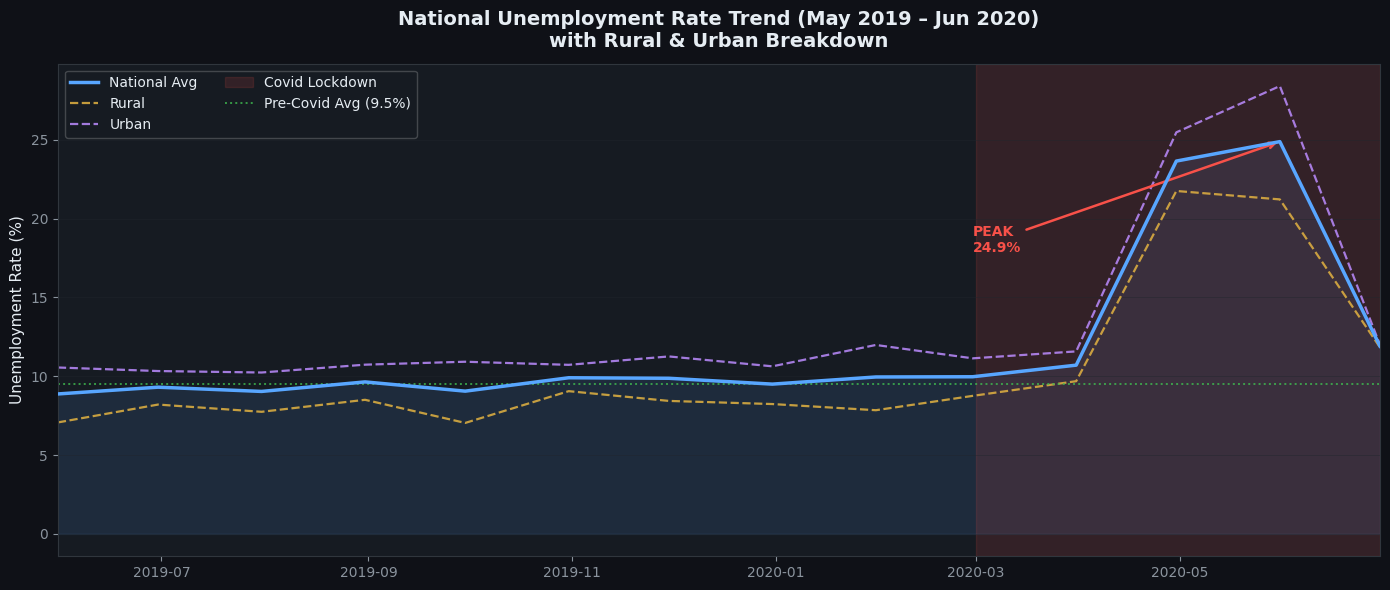

In [43]:
base_style()
fig, ax = plt.subplots(figsize=(14, 6), facecolor=DARK)
ax.set_facecolor(PANEL)

ax.fill_between(national['Date'], national['Avg_Rate'], alpha=0.12, color=ACCENT)
ax.plot(national['Date'], national['Avg_Rate'],
        color=ACCENT, linewidth=2.5, zorder=5, label='National Avg')

for area, clr in [('Rural', AMBER), ('Urban', PURPLE)]:
    sub = df[df['Area'] == area].groupby('Date')[col].mean().reset_index()
    ax.plot(sub['Date'], sub[col], color=clr, linewidth=1.6,
            alpha=0.85, linestyle='--', label=area)

ax.axvspan(pd.Timestamp('2020-03-01'), national['Date'].max(),
           alpha=0.13, color=RED, label='Covid Lockdown')
ax.axhline(pre_c.mean(), color=GREEN, linestyle=':', linewidth=1.4,
           alpha=0.8, label=f'Pre-Covid Avg ({pre_c.mean():.1f}%)')
ax.annotate(f"PEAK\n{peak['Avg_Rate']:.1f}%",
            xy=(peak['Date'], peak['Avg_Rate']),
            xytext=(peak['Date'] - pd.DateOffset(months=3), peak['Avg_Rate'] - 7),
            fontsize=10, color=RED, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.8))

ax.set_title('National Unemployment Rate Trend (May 2019 – Jun 2020)\nwith Rural & Urban Breakdown',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Unemployment Rate (%)', fontsize=11)
ax.legend(fontsize=10, framealpha=0.25, loc='upper left', ncol=2)
ax.grid(True, axis='y', alpha=0.6)
ax.set_xlim(national['Date'].min(), national['Date'].max())
plt.tight_layout()
plt.show()

### Chart 2 — State × Month Heatmap

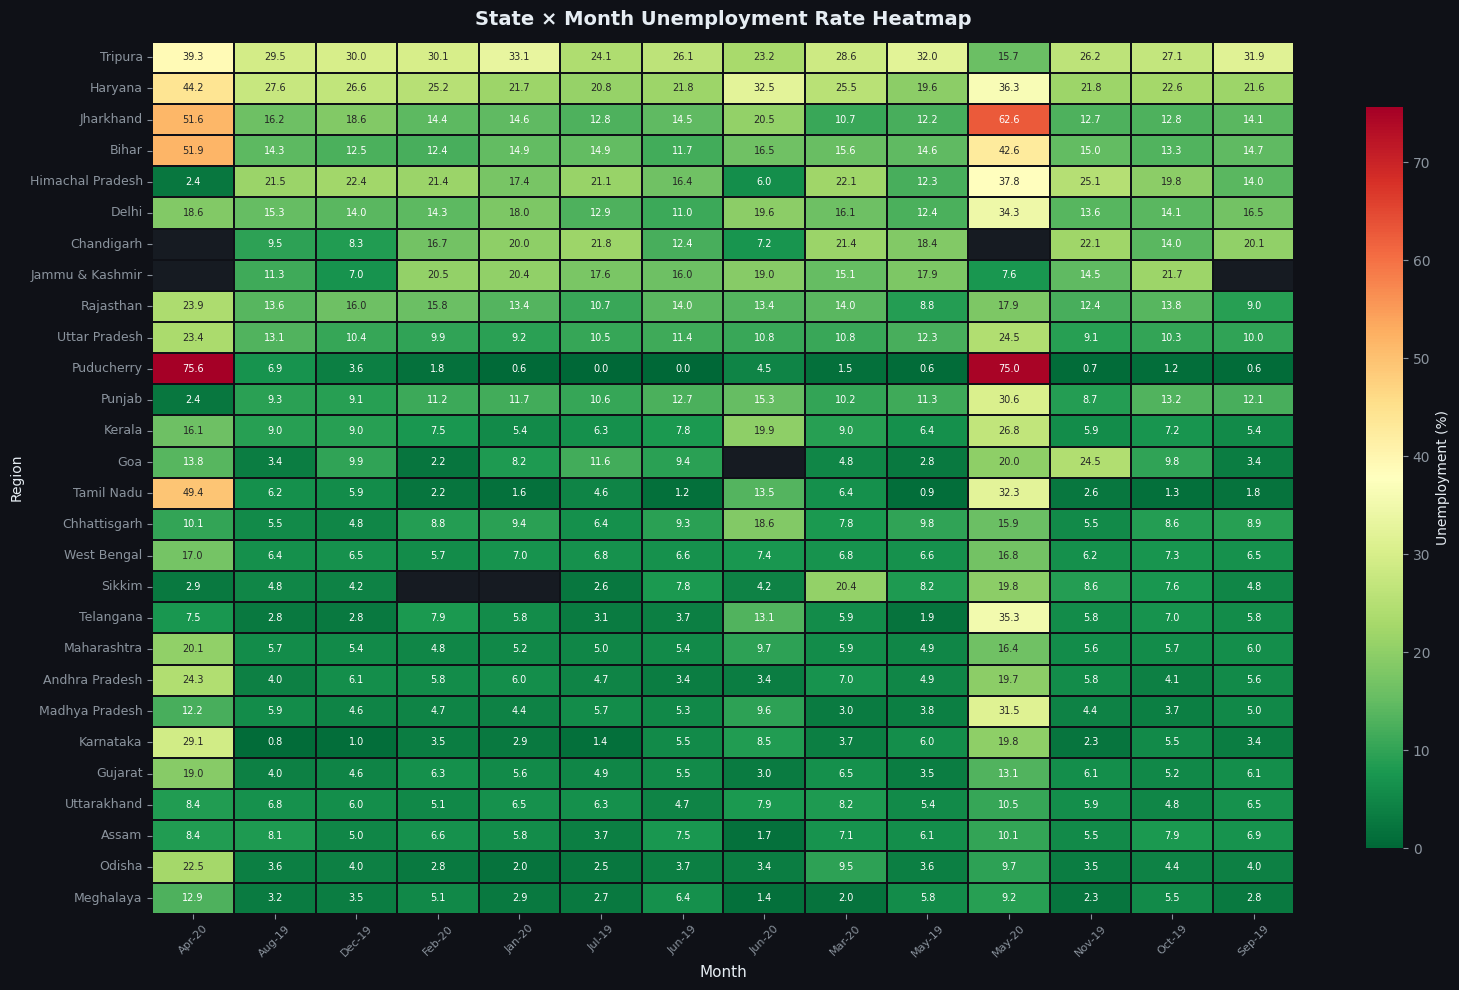

In [44]:
base_style()
fig, ax = plt.subplots(figsize=(16, 10), facecolor=DARK)
ax.set_facecolor(PANEL)

pivot = df.groupby(['Region', df['Date'].dt.strftime('%b-%y')])[col].mean().unstack()
month_order = df['Date'].dt.strftime('%b-%y').drop_duplicates().sort_values().tolist()
pivot = pivot.reindex(columns=month_order)
pivot = pivot.reindex(pivot.mean(axis=1).sort_values(ascending=False).index)

sns.heatmap(pivot, ax=ax, cmap='RdYlGn_r', annot=True, fmt='.1f',
            linewidths=0.25, linecolor=DARK, annot_kws={'size': 7},
            cbar_kws={'label': 'Unemployment (%)', 'shrink': 0.85})
ax.set_title('State × Month Unemployment Rate Heatmap',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=11)
ax.tick_params(axis='x', labelsize=8, rotation=45)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

### Chart 3 — Covid-19 Impact

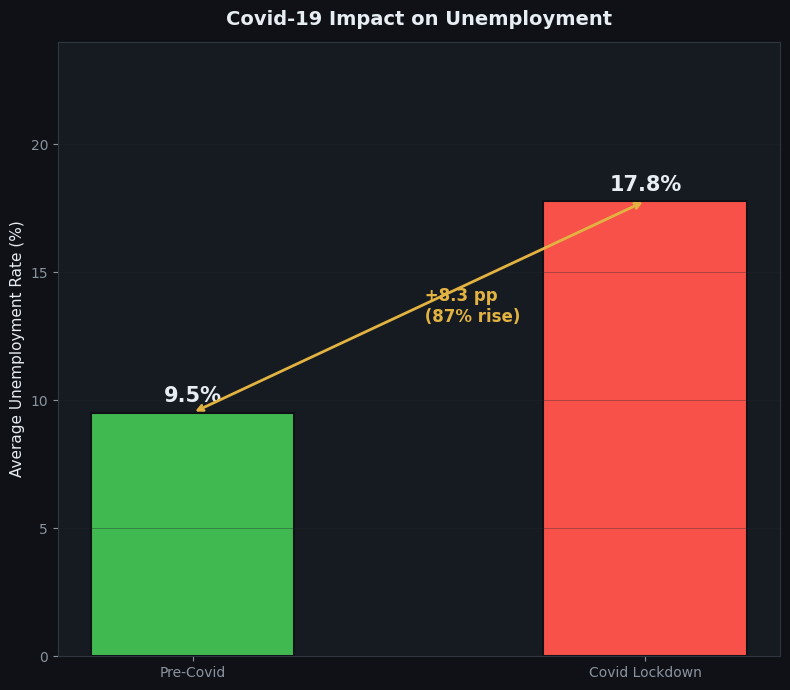

In [45]:
base_style()
fig, ax = plt.subplots(figsize=(8, 7), facecolor=DARK)
ax.set_facecolor(PANEL)

period_avg = df.groupby('Period')[col].mean()[['Pre-Covid', 'Covid Lockdown']]
bars = ax.bar(['Pre-Covid', 'Covid Lockdown'], period_avg.values,
              color=[GREEN, RED], width=0.45, edgecolor=DARK, linewidth=1.5)
for bar, val in zip(bars, period_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{val:.1f}%', ha='center', fontsize=15, fontweight='bold', color=LIGHT)

diff = period_avg['Covid Lockdown'] - period_avg['Pre-Covid']
ax.annotate('', xy=(1, period_avg['Covid Lockdown']),
            xytext=(0, period_avg['Pre-Covid']),
            arrowprops=dict(arrowstyle='<->', color=AMBER, lw=2))
ax.text(0.5, (period_avg['Pre-Covid'] + period_avg['Covid Lockdown']) / 2,
        f' +{diff:.1f} pp\n ({diff/period_avg["Pre-Covid"]*100:.0f}% rise)',
        ha='left', va='center', fontsize=12, color=AMBER, fontweight='bold')

ax.set_title('Covid-19 Impact on Unemployment', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Average Unemployment Rate (%)', fontsize=11)
ax.set_ylim(0, period_avg.max() * 1.35)
ax.grid(True, axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

### Chart 4 — Monthly / Seasonal Trend

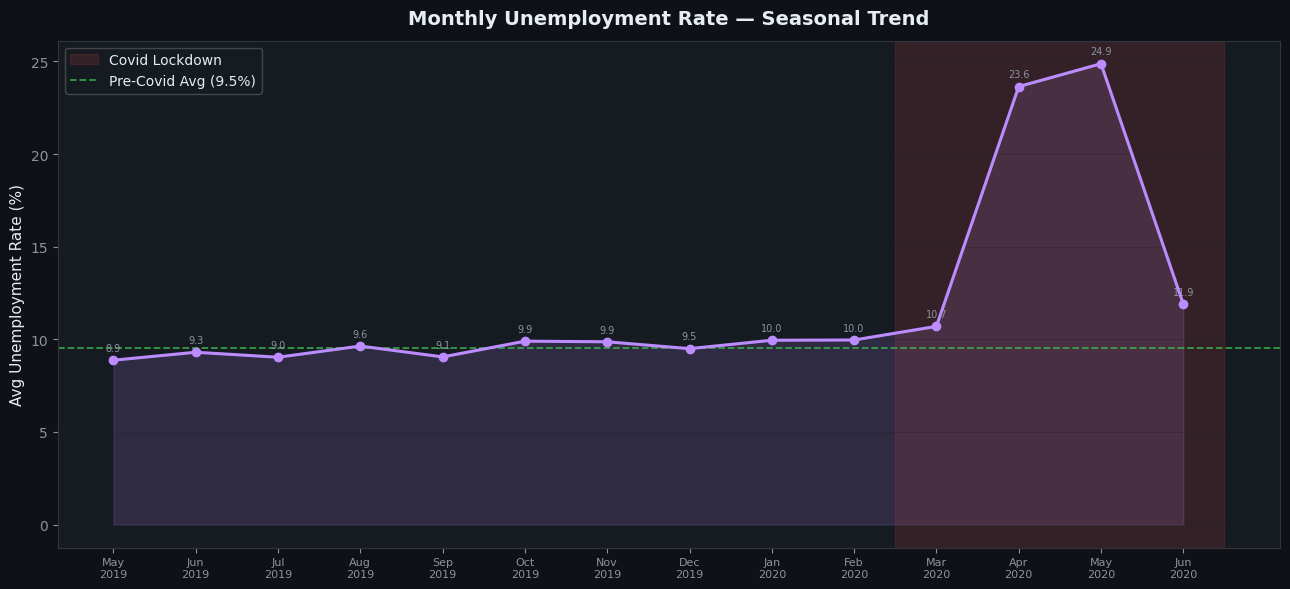

In [46]:
base_style()
fig, ax = plt.subplots(figsize=(13, 6), facecolor=DARK)
ax.set_facecolor(PANEL)

seasonal = df.groupby(df['Date'].dt.strftime('%Y-%m'))[col].mean().reset_index()
seasonal['Date'] = pd.to_datetime(seasonal['Date'])
seasonal = seasonal.sort_values('Date').reset_index(drop=True)

ax.plot(range(len(seasonal)), seasonal[col],
        color=PURPLE, linewidth=2.2, marker='o', markersize=6, zorder=5)
ax.fill_between(range(len(seasonal)), seasonal[col], alpha=0.15, color=PURPLE)

lockdown_idx = seasonal[seasonal['Date'] >= pd.Timestamp('2020-03-01')].index[0]
ax.axvspan(lockdown_idx - 0.5, len(seasonal) - 0.5,
           alpha=0.13, color=RED, label='Covid Lockdown')
ax.axhline(pre_c.mean(), color=GREEN, linestyle='--', linewidth=1.3,
           alpha=0.8, label=f'Pre-Covid Avg ({pre_c.mean():.1f}%)')

for i, row in seasonal.iterrows():
    ax.text(i, row[col] + 0.5, f"{row[col]:.1f}", ha='center', fontsize=7, color=MUTED)

ax.set_xticks(range(len(seasonal)))
ax.set_xticklabels(seasonal['Date'].dt.strftime('%b\n%Y'), fontsize=8)
ax.set_title('Monthly Unemployment Rate — Seasonal Trend', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Avg Unemployment Rate (%)', fontsize=11)
ax.legend(fontsize=10, framealpha=0.25)
ax.grid(True, axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

### Chart 5 — State Rankings

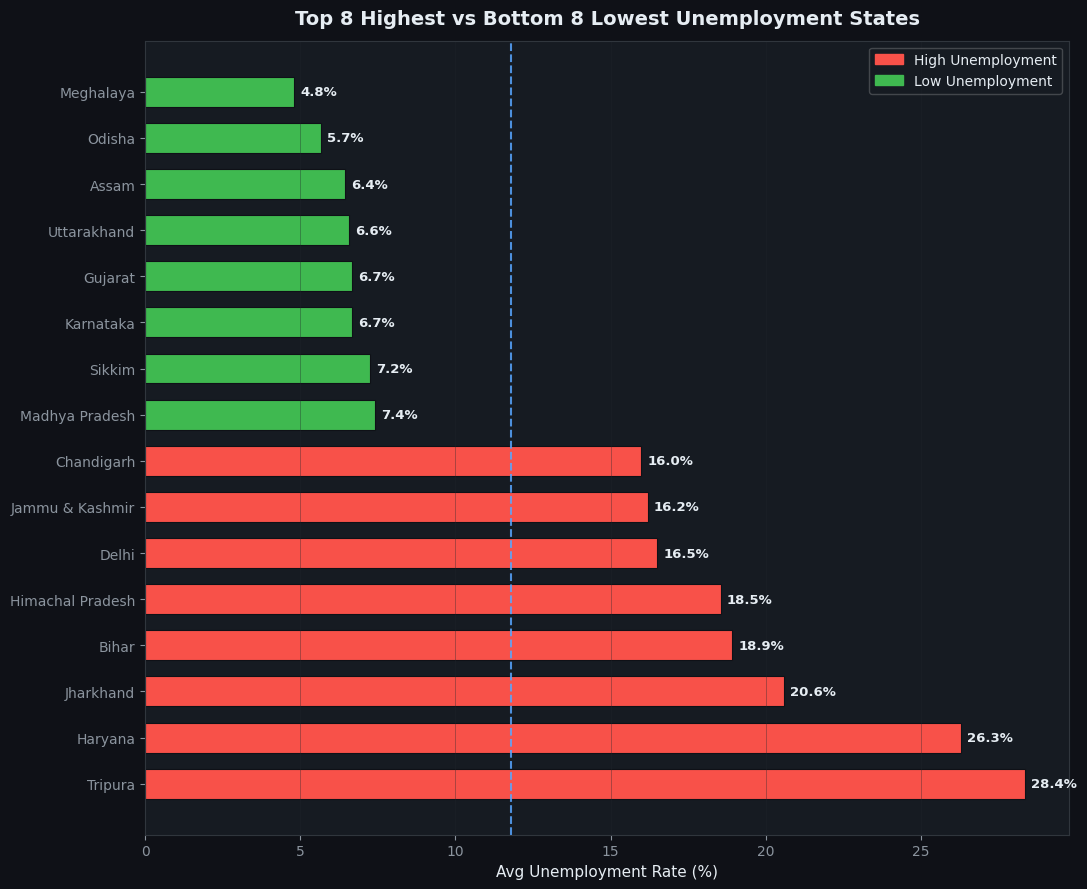

In [47]:
base_style()
fig, ax = plt.subplots(figsize=(11, 9), facecolor=DARK)
ax.set_facecolor(PANEL)

top8 = state_avg.head(8)
bot8 = state_avg.tail(8)
combined = pd.concat([top8, bot8])
colors_h = [RED if v >= state_avg.median() else GREEN for v in combined.values]
bars_h = ax.barh(combined.index, combined.values, color=colors_h,
                 edgecolor=DARK, linewidth=0.8, height=0.65)
ax.axvline(state_avg.mean(), color=ACCENT, linestyle='--', linewidth=1.5,
           alpha=0.85, label=f'National Avg ({state_avg.mean():.1f}%)')
for bar, val in zip(bars_h, combined.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9.5, color=LIGHT, fontweight='bold')

p1 = mpatches.Patch(color=RED,   label='High Unemployment')
p2 = mpatches.Patch(color=GREEN, label='Low Unemployment')
ax.legend(handles=[p1, p2], fontsize=10, framealpha=0.25)
ax.set_title('Top 8 Highest vs Bottom 8 Lowest Unemployment States',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Avg Unemployment Rate (%)', fontsize=11)
ax.grid(True, axis='x', alpha=0.5)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()

### Chart 6 — Rural vs Urban by State

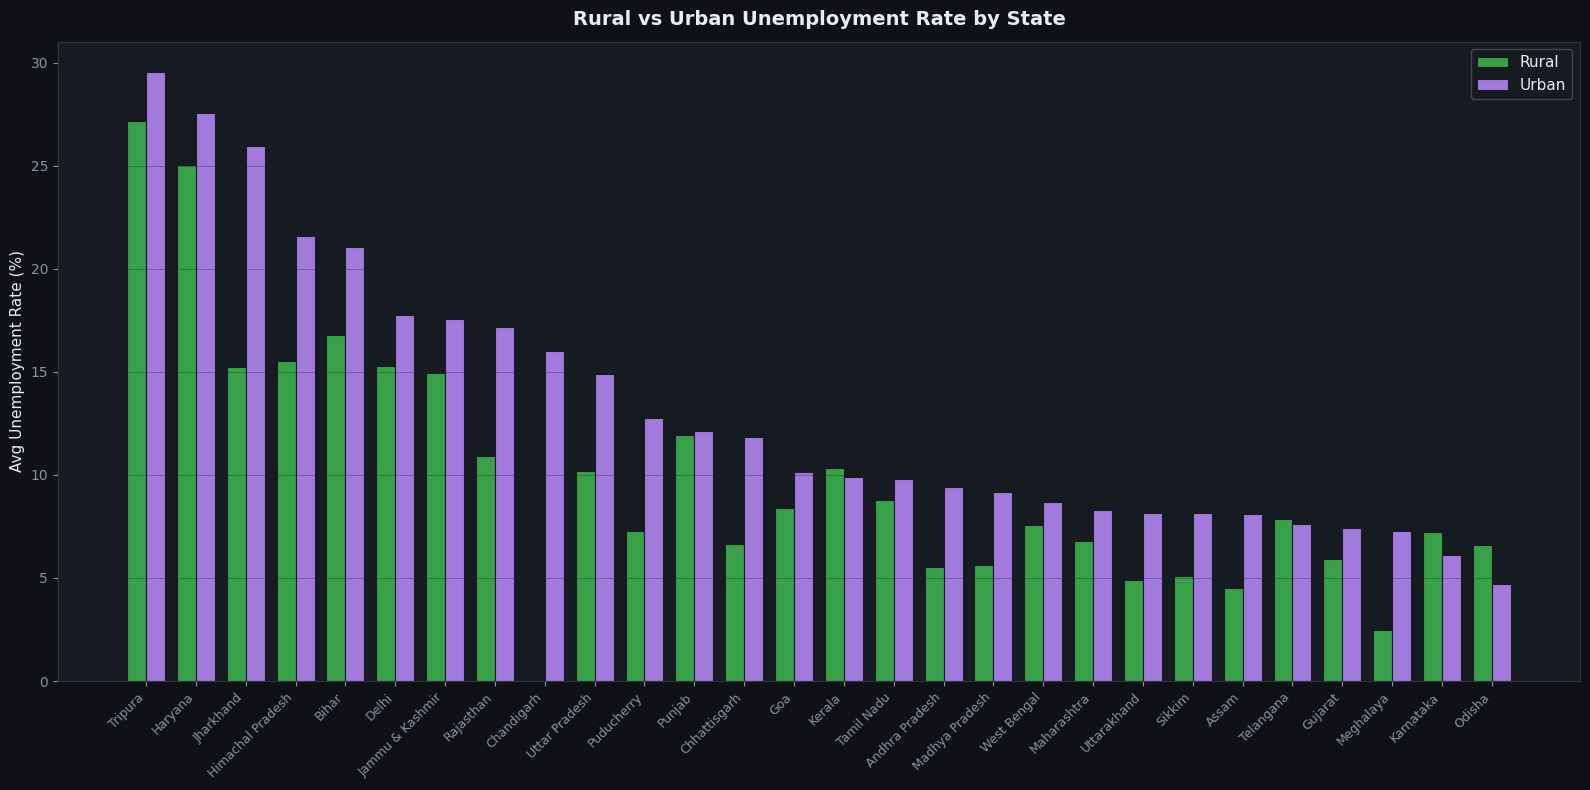

In [48]:
base_style()
fig, ax = plt.subplots(figsize=(16, 8), facecolor=DARK)
ax.set_facecolor(PANEL)

ru_state = (df[df['Area'].isin(['Rural', 'Urban'])]
            .groupby(['Region', 'Area'])[col].mean().unstack())
ru_state = ru_state.sort_values('Urban', ascending=False)
x = np.arange(len(ru_state))
w = 0.38
ax.bar(x - w/2, ru_state['Rural'], w, color=GREEN, alpha=0.85,
       edgecolor=DARK, linewidth=0.8, label='Rural')
ax.bar(x + w/2, ru_state['Urban'], w, color=PURPLE, alpha=0.85,
       edgecolor=DARK, linewidth=0.8, label='Urban')
ax.set_xticks(x)
ax.set_xticklabels(ru_state.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Rural vs Urban Unemployment Rate by State',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Avg Unemployment Rate (%)', fontsize=11)
ax.legend(fontsize=11, framealpha=0.25)
ax.grid(True, axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

### Chart 7 — Labour Participation vs Unemployment Scatter

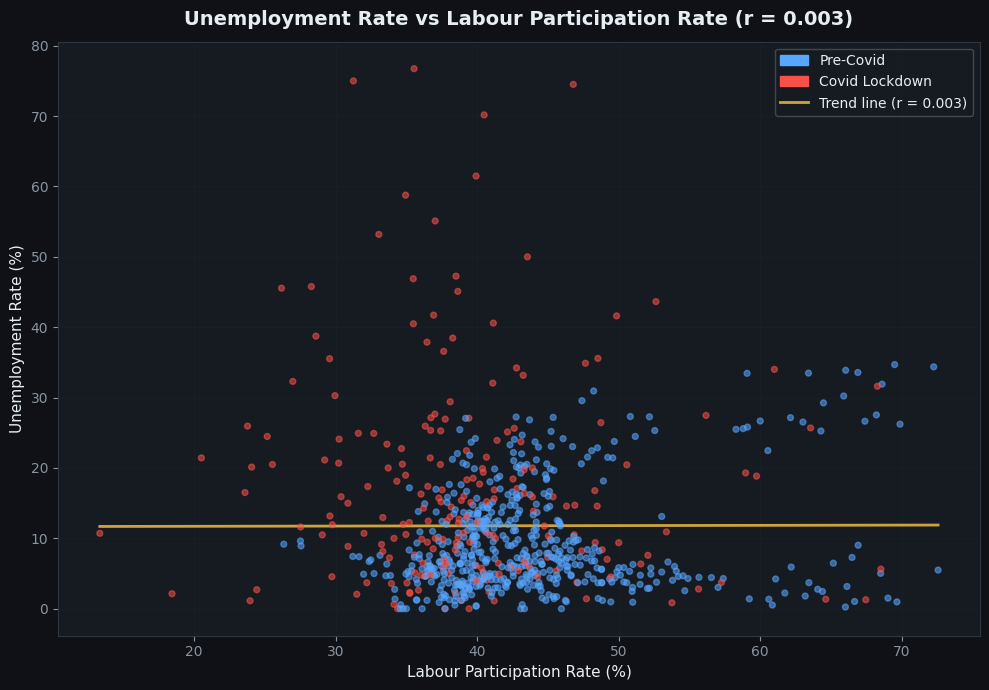

In [49]:
base_style()
fig, ax = plt.subplots(figsize=(10, 7), facecolor=DARK)
ax.set_facecolor(PANEL)

colors_sc = df['Period'].map({'Pre-Covid': ACCENT, 'Covid Lockdown': RED})
ax.scatter(df[lpr], df[col], c=colors_sc, s=18, alpha=0.55, zorder=5)

m, b_val = np.polyfit(df[lpr], df[col], 1)
x_line = np.linspace(df[lpr].min(), df[lpr].max(), 100)
ax.plot(x_line, m*x_line + b_val, color=AMBER, linewidth=2, alpha=0.9,
        label=f'Trend line (r = {r_val:.3f})')

p1 = mpatches.Patch(color=ACCENT, label='Pre-Covid')
p2 = mpatches.Patch(color=RED,    label='Covid Lockdown')
ax.legend(handles=[p1, p2, ax.lines[0]], fontsize=10, framealpha=0.25)
ax.set_title(f'Unemployment Rate vs Labour Participation Rate (r = {r_val:.3f})',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Labour Participation Rate (%)', fontsize=11)
ax.set_ylabel('Unemployment Rate (%)', fontsize=11)
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

---
## 7. 💡 Key Insights & Policy Recommendations

### 🦠 1. Covid-19 Shock
- National unemployment **surged from ~9.5% to ~17.8%** during the lockdown — a **+8.3 percentage point** rise (+87%).
- The peak was recorded in **May 2020 at 24.9%**, coinciding with the strictest phase of India's national lockdown.
- **Urban areas were harder hit** (19.3%) than rural (16.2%), reflecting the concentration of formal sector and services jobs in cities.

### 🗺️ 2. Regional Inequality
- **Tripura, Haryana & Jharkhand** consistently top the unemployment charts.
- **Meghalaya, Odisha & Karnataka** maintain the lowest rates.
- The spread across states exceeds **20 percentage points**, pointing to deep structural imbalances in industrialisation and skill mix.

### 🌾 3. Seasonal Trends
- Unemployment shows a **gradual decline from May to Nov 2019**, aligning with the **Kharif agricultural season** when rural labour demand peaks.
- A sharp rise begins from **March 2020**, directly driven by Covid-19 lockdowns — not a natural seasonal pattern.

### 👥 4. Rural vs Urban Divide
- Urban unemployment is **structurally higher** than rural across most states.
- The Covid shock **disproportionately compressed urban employment**, especially in trade, hospitality, and construction.

### 📉 5. Labour Participation Rate
- Near-zero correlation (r ≈ 0.003) between LPR and unemployment suggests that **many discouraged workers simply exit the labour force**, masking true unemployment.

---

### ✅ Policy Recommendations

| # | Recommendation |
|---|---|
| 1 | **Scale MGNREGS** as a counter-cyclical rural employment buffer during crises |
| 2 | **Urban reskilling programs** (PM Kaushal Vikas) targeting services & gig workers |
| 3 | **Targeted industrial investment** in high-unemployment states (Tripura, Haryana) |
| 4 | **Real-time state-level dashboards** for faster policy responses in future crises |
| 5 | **Increase female labour participation** through childcare support and flexible work policies |

---

## 8. 📌 Conclusion

This analysis of India's unemployment data reveals that while pre-Covid unemployment was moderate (~9.5%), the **Covid-19 lockdown caused the sharpest labour market shock** in the dataset — nearly doubling the national rate. Urban workers and states with high dependence on the formal sector were the most vulnerable. Recovery requires targeted, region-specific policies that address both structural unemployment and crisis-driven job losses.

---
*Notebook created for internship project submission.*